# Predicting Insurance Claim Amounts

**Regression modeling on the Medical Cost Personal Dataset**

The goal here is pretty straightforward: given a person's age, BMI, smoking status, etc.,
can we predict roughly how much their medical insurance charges will be? I'll walk through
the usual steps — load and clean the data, look at how the features relate to charges,
fit a linear regression model, and then check how good (or not) the predictions actually are.

**Dataset:** `insurance.csv` — 1338 records, 7 columns (age, sex, bmi, children, smoker, region, charges).
This is the well-known "Medical Cost Personal" dataset that gets used a lot for regression practice.


## 1. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# just so the notebook looks the same every time it's re-run
RANDOM_STATE = 42

## 2. Load the data and take a first look

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

A quick `.info()` to check data types and make sure there's nothing weird going on with
missing values before we go any further.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Numeric summary looks sane — nobody's BMI is negative, ages range from 18 to 64, that all
checks out. Let's check for nulls and duplicate rows too, since those can quietly mess up a
model if you don't catch them early.

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Number of exact duplicate rows:", df.duplicated().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of exact duplicate rows: 1


There's one duplicate row. Not a big deal with 1338 rows total, but no reason to keep it
around — I'll drop it before doing anything else.

In [7]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(1337, 7)

Down to 1337 unique rows. Also worth a quick look at the categorical columns just to know
what we're working with.

In [8]:
for col in ["sex", "smoker", "region"]:
    print(col, "->", df[col].unique())

sex -> <StringArray>
['female', 'male']
Length: 2, dtype: str
smoker -> <StringArray>
['yes', 'no']
Length: 2, dtype: str
region -> <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


## 3. Exploring the relationships (feature correlation & visualization)

Before fitting anything, I want to actually *see* how age, BMI, and smoking relate to charges.
The instructions specifically ask for this, and honestly it's also just the most useful part —
the model coefficients later will basically confirm what these plots already show.

### 3.1 Correlation matrix

`charges` correlates with categorical columns is awkward to compute directly, so I'll encode
`smoker` and `sex` as 0/1 just for this correlation check (this is separate from the proper
one-hot encoding used in the actual model later).

In [9]:
corr_df = df.copy()
corr_df["smoker_num"] = corr_df["smoker"].map({"yes": 1, "no": 0})
corr_df["sex_num"] = corr_df["sex"].map({"male": 1, "female": 0})

corr_cols = ["age", "bmi", "children", "smoker_num", "sex_num", "charges"]
corr_matrix = corr_df[corr_cols].corr()
corr_matrix["charges"].sort_values(ascending=False)

charges       1.000000
smoker_num    0.787234
age           0.298308
bmi           0.198401
children      0.067389
sex_num       0.058044
Name: charges, dtype: float64

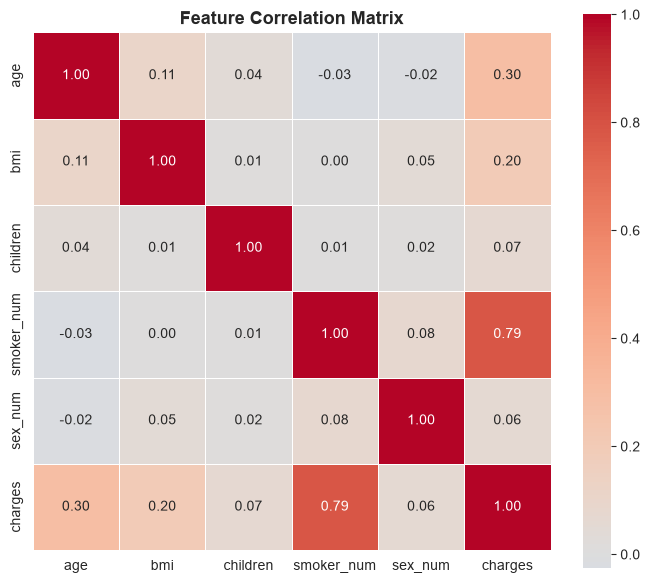

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

Smoking status jumps out immediately — a 0.79 correlation with charges, way higher than
anything else. Age comes in a distant second at 0.30, and BMI is even weaker at 0.20 on its
own. That last part is a little misleading though, as the next plots show — BMI matters a lot
*if* you're also a smoker, but the plain correlation coefficient doesn't capture that
interaction.

### 3.2 Age and BMI vs. charges, split by smoking status

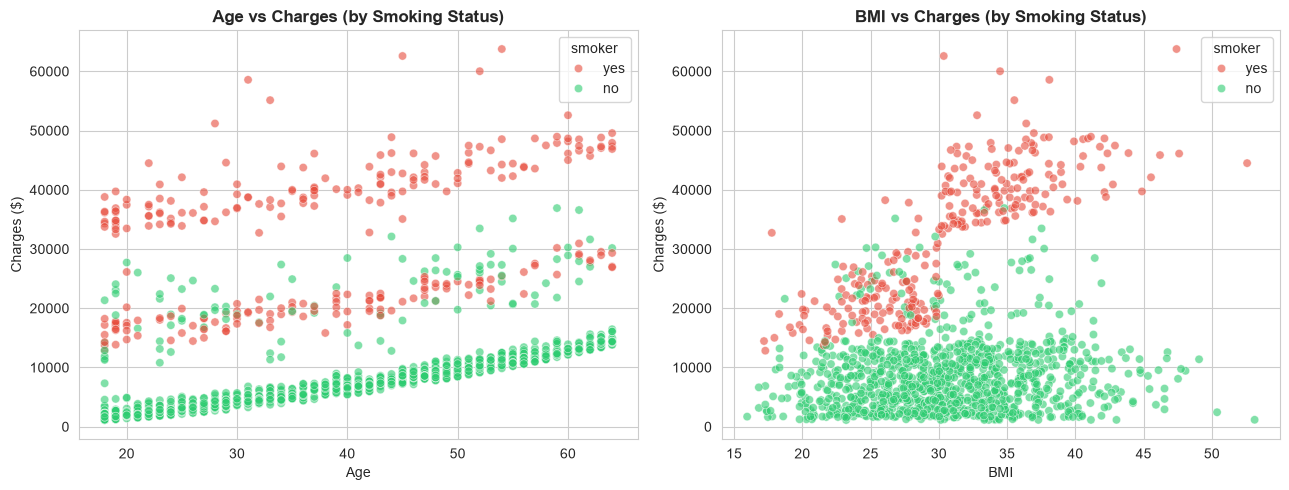

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="age", y="charges", hue="smoker",
                 palette={"yes": "#e74c3c", "no": "#2ecc71"}, alpha=0.6, ax=axes[0])
axes[0].set_title("Age vs Charges (by Smoking Status)", weight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Charges ($)")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker",
                 palette={"yes": "#e74c3c", "no": "#2ecc71"}, alpha=0.6, ax=axes[1])
axes[1].set_title("BMI vs Charges (by Smoking Status)", weight="bold")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Charges ($)")

plt.tight_layout()
plt.show()

A couple of things stand out here:

- **Age (left plot):** both smokers and non-smokers show a clear upward trend with age — that
  makes sense, older people generally rack up more medical costs. But smokers sit on a whole
  separate, much higher band than non-smokers at every age.
- **BMI (right plot):** for non-smokers, BMI barely seems to matter — the green dots are pretty
  flat across the BMI range. For smokers (red), though, there's a visible jump once BMI crosses
  roughly 30. Below that, smoker charges look similar to non-smokers; above it, charges shoot up
  into the $40k+ range. That's the obesity + smoking combination doing real damage, and it's an
  interaction effect that a plain linear model (without an interaction term) won't fully capture.

### 3.3 Smokers vs. non-smokers, directly

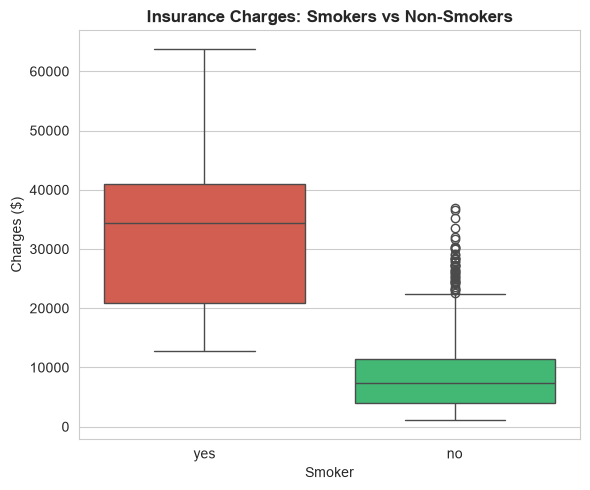

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker",
            palette={"yes": "#e74c3c", "no": "#2ecc71"}, legend=False, ax=ax)
ax.set_title("Insurance Charges: Smokers vs Non-Smokers", weight="bold")
ax.set_xlabel("Smoker")
ax.set_ylabel("Charges ($)")
plt.tight_layout()
plt.show()

In [13]:
df.groupby("smoker")["charges"].median()

smoker
no      7345.72660
yes    34456.34845
Name: charges, dtype: float64

Smokers' median charge is about 5x that of non-smokers. This one variable alone explains
most of why some people get charged so much more than others.

### 3.4 All three together: BMI, age, and smoking on one plot

Just to tie it together — here's BMI vs. charges again, but colored by age and with smokers
drawn bigger and outlined in red, so all three variables are visible at once.

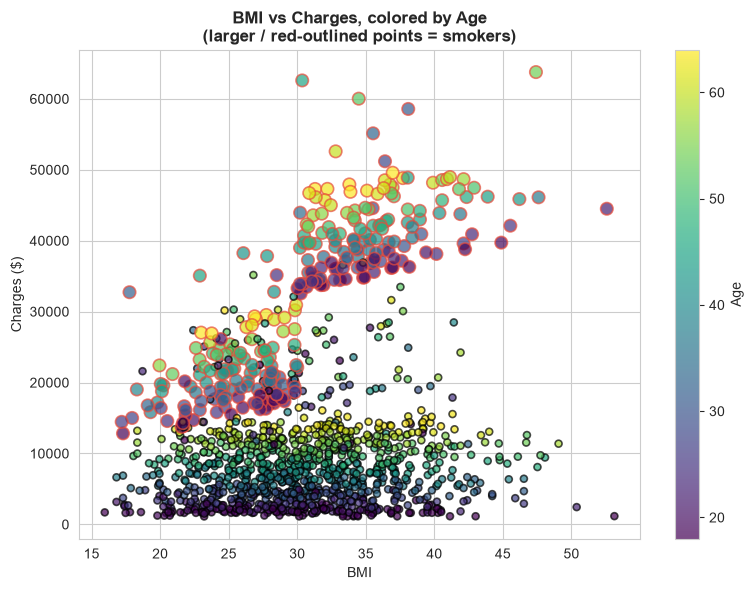

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    df["bmi"], df["charges"],
    c=df["age"], cmap="viridis",
    s=df["smoker"].map({"yes": 80, "no": 25}),
    alpha=0.7,
    edgecolors=df["smoker"].map({"yes": "#e74c3c", "no": "none"}),
    linewidths=1.2,
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Age")
ax.set_title("BMI vs Charges, colored by Age\n(larger / red-outlined points = smokers)", weight="bold")
ax.set_xlabel("BMI")
ax.set_ylabel("Charges ($)")
plt.tight_layout()
plt.show()

You can actually see all three effects layered on top of each other here: charges generally
rise as you move right (older people, lighter colors trending up at the bottom band), the
red-outlined smoker cluster sits way above everyone else, and within that cluster, the
highest charges concentrate on the right side (higher BMI). That upper-right cluster — older
smokers with high BMI — is clearly the most expensive group in the dataset.

## 4. Preparing the data for modeling

Linear regression needs numeric input, so the categorical columns (`sex`, `smoker`, `region`)
need to be one-hot encoded. I'm using a `ColumnTransformer` + `Pipeline` here mainly so the
encoding logic travels with the model — it's less to keep track of than encoding manually and
makes the whole thing reusable later.

In [15]:
X = df.drop(columns=["charges"])
y = df["charges"]

categorical_features = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi", "children"]

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 1069
Test rows: 268


`drop="first"` on the one-hot encoder avoids the dummy-variable trap (one category per
feature gets folded into the intercept). 80/20 train-test split, with a fixed random state so
results are reproducible if this gets re-run.

## 5. Training the linear regression model

In [16]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model trained.")

Model trained.


That's it — that's the whole training step. Linear regression doesn't need much tuning,
which is part of why it's a good baseline model for this kind of problem.

## 6. Evaluating performance: MAE and RMSE

Two error metrics were asked for:

- **MAE (Mean Absolute Error):** average size of the error, in dollars, treating all errors
  the same regardless of direction.
- **RMSE (Root Mean Squared Error):** similar idea, but squares the errors first, which makes
  it more sensitive to a few really bad predictions.

I'll also throw in R² since it's a useful sanity check for "how much of the variance does this
model actually explain," even though it wasn't explicitly requested.

In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R^2  : {r2:.4f}")
print()
print(f"For reference, average charge in the test set is ${y_test.mean():,.2f}")

MAE  : $4,177.05
RMSE : $5,956.34
R^2  : 0.8069

For reference, average charge in the test set is $14,272.01


So on average, predictions are off by around $4,100-4,200 (MAE), and the RMSE being
noticeably higher than the MAE ($5,900-ish vs $4,100-ish) tells us there are some predictions
that miss by a lot more than the "typical" miss — which lines up with what the BMI/smoker plot
showed earlier. An R² around 0.80 means the model is explaining roughly 80% of the variation in
charges, which is solid for a simple linear model on data that we already know has a
non-linear interaction baked into it (the BMI × smoker effect).

Let's also run a quick 5-fold cross-validation, just to make sure the test-set numbers above
aren't a fluke of how the train/test split happened to land.

In [18]:
cv_mae_scores = -cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error")
print("CV MAE per fold:", np.round(cv_mae_scores, 2))
print(f"Mean CV MAE: ${cv_mae_scores.mean():,.2f}  (+/- ${cv_mae_scores.std():,.2f})")

CV MAE per fold: [4240.04 4260.92 4024.59 4256.73 4216.75]
Mean CV MAE: $4,199.80  (+/- $88.97)


Consistent with the single test-set MAE, so the result looks stable rather than lucky.

## 7. Looking inside the model: which features matter most?

Linear regression has the nice property that you can just read the coefficients to see what's
driving the predictions. Higher coefficient = bigger effect on predicted charges (in dollars,
per unit of that feature).

In [19]:
feature_names = numeric_features + list(
    model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

coefs = model.named_steps["regressor"].coef_
intercept = model.named_steps["regressor"].intercept_

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df = coef_df.sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
coef_df

,feature,coefficient
0,smoker_yes,23077.764593
1,region_southeast,-838.919616
2,region_southwest,-659.139752
3,children,533.009989
4,region_northwest,-391.761455
5,bmi,318.701441
6,age,248.210720
7,sex_male,-101.542054


In [20]:
print(f"Intercept: {intercept:,.2f}")

Intercept: -11,092.65


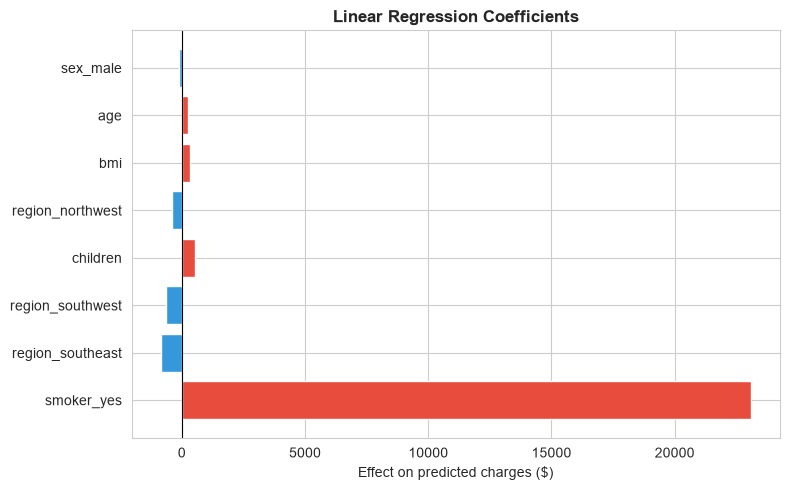

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Linear Regression Coefficients", weight="bold")
ax.set_xlabel("Effect on predicted charges ($)")
plt.tight_layout()
plt.show()

No surprise given everything above — `smoker_yes` dwarfs every other coefficient,
adding roughly **$23,000** to the predicted charge, all else being equal. Age and BMI both have
small positive coefficients (a few hundred dollars per unit), children adds a modest amount, and
region/sex barely move the needle. This matches the correlation matrix from earlier almost
exactly, which is reassuring — the model isn't picking up on anything weird that the EDA didn't
already hint at.

## 8. Predicted vs. actual, and residuals

Two more diagnostic plots: one comparing predictions to actual charges directly, and one looking
at the residuals (actual minus predicted) to check for patterns the model is missing.

<>:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\ayesh\AppData\Local\Temp\ipykernel_16628\1540706701.py:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.set_title(f"Predicted vs Actual Charges\nMAE = \${mae:,.0f}   |   RMSE = \${rmse:,.0f}   |   R2 = {r2:.3f}",
C:\Users\ayesh\AppData\Local\Temp\ipykernel_16628\1540706701

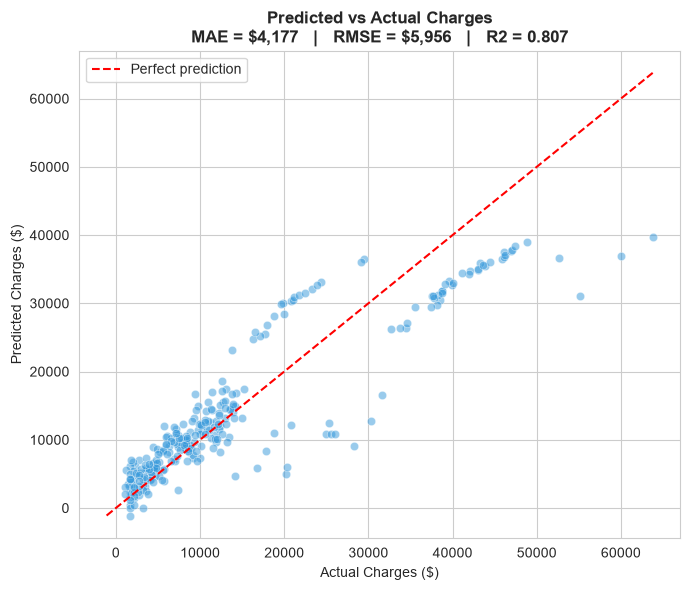

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color="#3498db", edgecolors="white", linewidths=0.5)

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")

ax.set_xlabel("Actual Charges ($)")
ax.set_ylabel("Predicted Charges ($)")
ax.set_title(f"Predicted vs Actual Charges\nMAE = \${mae:,.0f}   |   RMSE = \${rmse:,.0f}   |   R2 = {r2:.3f}",
             weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

Points along the red dashed line would be perfect predictions. Most of the lower-charge
points cluster reasonably close to the line, which is good. But notice the points sitting well
*below* the line in the $25k-40k actual range — those are cases the model underestimates,
and they're almost certainly the high-BMI smokers from the earlier scatter plot. A plain
linear model spreads the "smoker effect" evenly across all BMI levels, so it overshoots for
low-BMI smokers and undershoots for high-BMI ones.

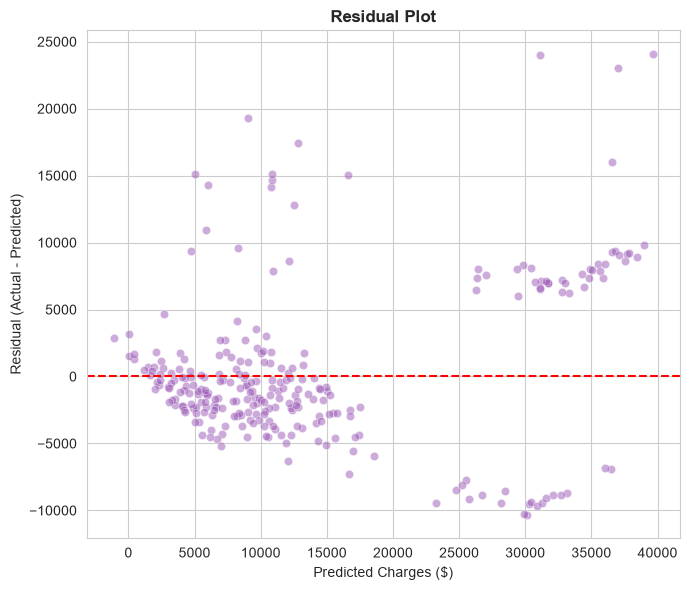

In [23]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_pred, residuals, alpha=0.5, color="#9b59b6", edgecolors="white", linewidths=0.5)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted Charges ($)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Residual Plot", weight="bold")
plt.tight_layout()
plt.show()

If the model were capturing everything well, these residuals would scatter randomly around
zero with no particular shape. Instead there's a visible cluster of large positive residuals
(actual much higher than predicted) around the $25k-32k predicted range, and a cluster of
large negative residuals further along. That's the signature of the missing
BMI × smoker interaction — confirming what the scatter plots suggested back in the
EDA section.

## 9. Summary

- **Smoking status is the single biggest driver of insurance charges** by a wide margin —
  it shows the strongest correlation with charges (0.79) and the largest model coefficient
  (~$23,000).
- **Age** has a steady, roughly linear relationship with charges, regardless of smoking status.
- **BMI** mostly only matters *combined with* smoking — high BMI plus smoking is the
  most expensive combination in the data, but a plain linear model can't fully represent that
  interaction, which shows up as a real pattern in the residuals.
- The model lands at **MAE ≈ \$4,177**, **RMSE ≈ \$5,956**, and **R² ≈ 0.81** on the test
  set, confirmed by 5-fold cross-validation. That's a reasonably strong baseline, but the
  residual pattern is a fair signal that a model allowing for interactions (e.g. adding a
  `bmi × smoker` feature, or trying a tree-based model like Random Forest) would likely close
  some of that remaining error.

**Possible next steps**, if this were taken further:
- Add an explicit `bmi * smoker` interaction term and refit
- Try a polynomial regression on `age` and `bmi`
- Compare against a Random Forest or Gradient Boosting regressor as a non-linear baseline
